In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch
from sklearn.metrics.pairwise import pairwise_distances

import pandas as pd
from itertools import permutations

In [2]:
colour = {
    'g': np.array([0, 158, 115])/256,
    'b': np.array([0, 114, 178])/256,
    'lb': np.array([86, 180, 233])/256,
    'r': np.array([213, 94, 0])/256,
    'o': np.array([230, 159, 0])/256,
    'y': np.array([240, 228, 66])/256,
    'p': np.array([204, 121, 167])/256,
    }

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
def moons():
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    # shuffle data and labels
    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def circles():
    X, y = make_circles(n_samples=1000, noise=0.05, factor=0.65)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def streched_gaussians():
    X, Labels = make_blobs(n_samples=1000, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)

    data = (X_aniso - X_aniso.mean(axis=0)) / X_aniso.std(axis=0)
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(Labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def combined_structure():
    data, labels = make_moons(n_samples=500, noise=0.1)

    # take the upper moons as data1
    data1 = data[labels == 0]
    data1[:, 0] = data1[:, 0] * 2

    # lower moon as data2
    data2 = data[labels == 1]

    # move and scale lower moon
    data2 = (data2 + np.array([-1, 1.5])) * -3

    # gaussian distribution at 0 0
    data3 = np.random.normal(loc=np.array([0, -1]), scale=0.65, size=(500, 2))

    labels = np.zeros(1000, dtype=int)
    labels[250:] = 1
    labels[500:] = 2
    
    data = np.vstack([data1, data2, data3])

    # standardize
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

def four_gaussians():
    n = 1000
    n_per_gaussian = n // 4

    g1 = np.random.normal(size=(n_per_gaussian, 2))
    g2 = np.random.normal(size=(n_per_gaussian, 2))
    g3 = np.random.normal(size=(n_per_gaussian, 2))
    g4 = np.random.normal(size=(n_per_gaussian, 2))

    g1[:, 0] -= 1.5
    g1[:, 1] -= 0.25

    g1 *= 0.75

    g2[:, 0] += 3
    g2[:, 1] += 3

    g2 *= 0.5

    g3[:, 0] += 3
    g3[:, 1] -= 1.5

    g3 *= 0.25

    g4[:, 0] -= 1.5
    g4[:, 1] += 3

    g4[:, 0] *= 0.15

    data = np.vstack([g1, g2, g3, g4])
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    labels = np.zeros(n, dtype=int)
    labels[n_per_gaussian:] = 1
    labels[2*n_per_gaussian:] = 2
    labels[3*n_per_gaussian:] = 3

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)
    

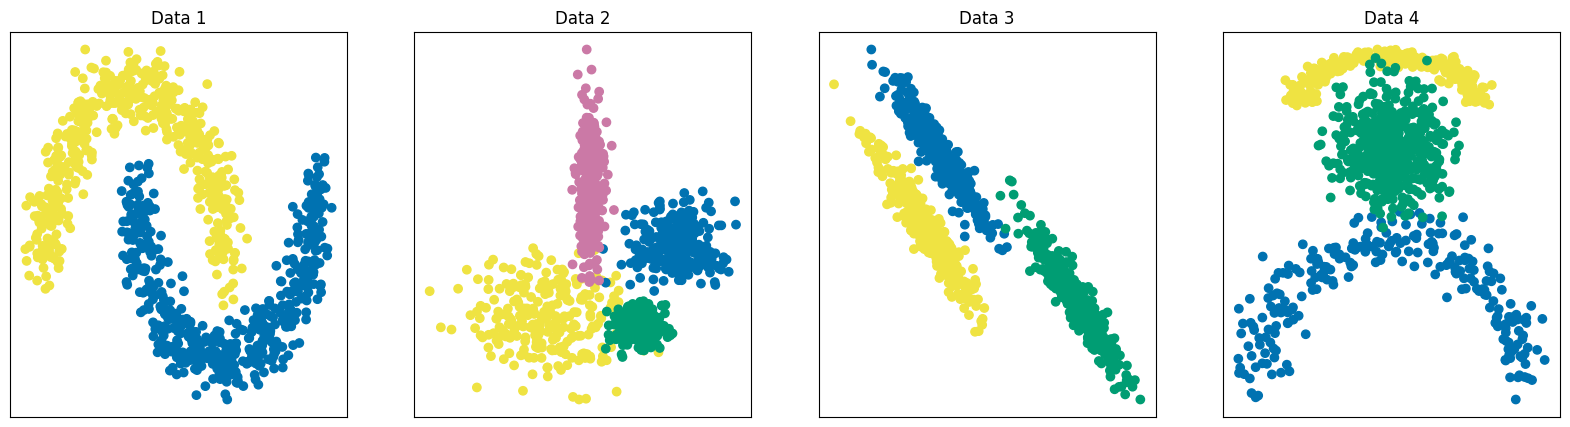

In [5]:
data1 = moons()
data2 = four_gaussians()
data3 = streched_gaussians()
data4 = combined_structure()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels) in enumerate([data1, data2, data3, data4]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['b'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['g'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()


In [6]:
def k_medoids(X, k, max_iter=100):
    """
    K-Medoids clustering algorithm
    :param X: numpy array of shape (n_samples, n_features)
    :param k: Number of clusters
    :param max_iter: Maximum number of iterations
    :return: (medoids, labels)
    """
    n_samples = X.shape[0]
    
    # Randomly initialize k medoids
    medoid_indices = np.random.choice(n_samples, k, replace=False)
    medoids = X[medoid_indices]
    
    for _ in range(max_iter):
        # Compute distance matrix
        distances = pairwise_distances(X, medoids, metric='manhattan')
        
        # Assign labels based on closest medoid
        labels = np.argmin(distances, axis=1)
        
        # Update medoids
        new_medoids = np.copy(medoids)
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                continue
            
            # Compute cost for each cluster point as new medoid
            costs = np.sum(pairwise_distances(cluster_points, cluster_points, metric='manhattan'), axis=1)
            new_medoids[i] = cluster_points[np.argmin(costs)]
        
        # Check for convergence
        # Fix: np.all() does not support axis=None for object arrays, use (new_medoids == medoids).all()
        if (new_medoids == medoids).all():
            break
        medoids = new_medoids
    
    return medoids, labels


def k_medoids_LAM(data, k, LAM, max_iter=100):
    # initialize medoids
    medoids = data[torch.randperm(data.size(0))[:k]]
    n = data.shape[0]
    
    for i in range(max_iter):
        # calculate distances
        idx, dists = LAM.query(medoids)
        
        dists = dists[idx < n].reshape(k, n)

        idx, sort_idx = torch.sort(idx, dim=1)
        for _ in range(k):
            dists[_] = dists[_, sort_idx[_]]

        # assign medoids
        _, assignments = dists.min(dim=0)
        new_medoids = torch.clone(medoids)
        # update medoids
        for j in range(k):
            
            # get indices of all points in the cluster j
            cluster_points = idx[j, assignments == j]

            if len(cluster_points) == 0:
                continue

            # get distance matrix of LAM
            distance_matrix, _ = LAMINAR.utils.dijkstra.dijkstra(LAM.graph, cluster_points.cpu().numpy(), cluster_points.cpu().numpy())
            
            distance_matrix = np.array(distance_matrix, dtype=np.float32)

            # only take rows and columns where cluster_points is True
            #distance_matrix = distance_matrix[cluster_points][:, cluster_points]

            distance_matrix = torch.tensor(distance_matrix, dtype=torch.float32)
            # sum over all columns
            sum = torch.sum(distance_matrix, dim=1)

            #print(sum)
            # minimum of the sum is the new medoid centre
            new_medoids[j] = data[cluster_points][sum.argmin()]

            #print('Lowest value in iteration', i, 'is', sum.min(), 'at', new_medoids[j])
            medoids = new_medoids
    return medoids, assignments

In [ ]:
def calculate_min_error_rate(ground_truth, predicted):
    # Convert tensors to numpy arrays if needed
    if isinstance(ground_truth, torch.Tensor):
        ground_truth = ground_truth.numpy()
    if isinstance(predicted, torch.Tensor):
        predicted = predicted.numpy()

    gt_labels = np.unique(ground_truth)
    pred_labels = np.unique(predicted)

    min_error_rate = float('inf')

    for perm in permutations(pred_labels):
        # Only map as many predicted labels as there are ground truth labels
        label_mapping = {pred_label: gt_label for pred_label, gt_label in zip(perm, gt_labels)}

        # For predicted labels not in mapping, assign a dummy label (e.g., -1)
        mapped_predicted = np.array([label_mapping.get(pred_label, -1) for pred_label in predicted])

        error_rate = np.mean(mapped_predicted != ground_truth)

        if error_rate < min_error_rate:
            min_error_rate = error_rate

    return min_error_rate

In [8]:
# make pd dataframe for each dataset and store error rates
eucl_error_rates = pd.DataFrame({'Dataset': ['Moons', 'Four Gaussians', 'Streched Gaussians', 'Combined Structure']})
lam_error_rates = pd.DataFrame({'Dataset': ['Moons', 'Four Gaussians', 'Streched Gaussians', 'Combined Structure']})

for i in range(20):   
    print(f"Iteration {i+1}")
    # do clustering for all datasets with euclidean metric 
    LAM1 = LAMINAR.LAMINAR(data1[0], drop_freq=9999, epochs=750)
    LAM2 = LAMINAR.LAMINAR(data2[0], drop_freq=9999, epochs=750)
    LAM3 = LAMINAR.LAMINAR(data3[0], drop_freq=9999, epochs=750)
    LAM4 = LAMINAR.LAMINAR(data4[0], drop_freq=9999, epochs=750)

    # do clustering for all datasets with euclidean metric

    medoids1_euc, labels1_euc = k_medoids(data1[0], 2)
    medoids2_euc, labels2_euc = k_medoids(data2[0], 4)
    medoids3_euc, labels3_euc = k_medoids(data3[0], 3)
    medoids4_euc, labels4_euc = k_medoids(data4[0], 3)

    # calculate error rates
    error_rate1_euc = calculate_min_error_rate(data1[1], labels1_euc)
    error_rate2_euc = calculate_min_error_rate(data2[1], labels2_euc)
    error_rate3_euc = calculate_min_error_rate(data3[1], labels3_euc)
    error_rate4_euc = calculate_min_error_rate(data4[1], labels4_euc)

    # store error rates in dataframe
    eucl_error_rates[f'Iteration {i+1}'] = [error_rate1_euc, error_rate2_euc, error_rate3_euc, error_rate4_euc]

    ###
    # same with LAM

    medoids1_lam, labels1_lam = k_medoids_LAM(data1[0], 2, LAM1)
    medoids2_lam, labels2_lam = k_medoids_LAM(data2[0], 4, LAM2)
    medoids3_lam, labels3_lam = k_medoids_LAM(data3[0], 3, LAM3)
    medoids4_lam, labels4_lam = k_medoids_LAM(data4[0], 3, LAM4)

    # calculate error rates
    error_rate1_lam = calculate_min_error_rate(data1[1], labels1_lam)
    error_rate2_lam = calculate_min_error_rate(data2[1], labels2_lam)
    error_rate3_lam = calculate_min_error_rate(data3[1], labels3_lam)
    error_rate4_lam = calculate_min_error_rate(data4[1], labels4_lam)

    # store error rates in dataframe
    lam_error_rates[f'Iteration {i+1}'] = [error_rate1_lam, error_rate2_lam, error_rate3_lam, error_rate4_lam]


    # save the dataframe
    eucl_error_rates.to_csv('euclidean_error_rates.csv', index=False)
    lam_error_rates.to_csv('lam_error_rates.csv', index=False)

Iteration 1
Iteration 0 | Train Loss: 981.6011352539062 | Validation Loss: 1637.277099609375
Iteration 99 | Train Loss: 262.0819091796875 | Validation Loss: 261.9151306152344
Iteration 199 | Train Loss: 240.0893096923828 | Validation Loss: 244.09910583496094
Iteration 299 | Train Loss: 210.0198211669922 | Validation Loss: 209.9308624267578
Iteration 399 | Train Loss: 197.6414794921875 | Validation Loss: 202.3121795654297
Iteration 499 | Train Loss: 198.26104736328125 | Validation Loss: 201.703857421875
Iteration 599 | Train Loss: 191.0200653076172 | Validation Loss: 202.1377410888672
Iteration 699 | Train Loss: 188.1976776123047 | Validation Loss: 207.4808349609375
Iteration 0 | Train Loss: 950.1831665039062 | Validation Loss: 1407.9002685546875
Iteration 99 | Train Loss: 278.9783020019531 | Validation Loss: 284.9866027832031
Iteration 199 | Train Loss: 207.4739532470703 | Validation Loss: 229.85552978515625
Iteration 299 | Train Loss: 195.66842651367188 | Validation Loss: 220.80970764

In [2]:
# read the dataframes
eucl_error_rates = pd.read_csv('euclidean_error_rates.csv')
lam_error_rates = pd.read_csv('lam_error_rates.csv')

In [3]:
eucl_error_rates

,Dataset,Iteration 1,Iteration 2,Iteration 3,Iteration 4,Iteration 5,Iteration 6,Iteration 7,Iteration 8,Iteration 9,...,Iteration 11,Iteration 12,Iteration 13,Iteration 14,Iteration 15,Iteration 16,Iteration 17,Iteration 18,Iteration 19,Iteration 20
0,Moons,0.157,0.157,0.166,0.166,0.166,0.166,0.166,0.166,0.166,...,0.166,0.166,0.166,0.166,0.162,0.166,0.157,0.166,0.166,0.167
1,Four Gaussians,0.053,0.370,0.053,0.053,0.053,0.053,0.383,0.053,0.053,...,0.053,0.053,0.053,0.385,0.053,0.388,0.053,0.053,0.055,0.053
2,Streched Gaussians,0.448,0.212,0.467,0.194,0.194,0.215,0.191,0.448,0.194,...,0.215,0.215,0.467,0.212,0.212,0.215,0.467,0.194,0.194,0.194
3,Combined Structure,0.295,0.395,0.359,0.217,0.459,0.102,0.286,0.407,0.462,...,0.388,0.409,0.248,0.395,0.375,0.376,0.323,0.500,0.379,0.422


In [4]:
lam_error_rates

,Dataset,Iteration 1,Iteration 2,Iteration 3,Iteration 4,Iteration 5,Iteration 6,Iteration 7,Iteration 8,Iteration 9,...,Iteration 11,Iteration 12,Iteration 13,Iteration 14,Iteration 15,Iteration 16,Iteration 17,Iteration 18,Iteration 19,Iteration 20
0,Moons,0.089,0.067,0.035,0.046,0.121,0.032,0.012,0.064,0.043,...,0.422,0.100,0.079,0.101,0.067,0.051,0.072,0.061,0.039,0.090
1,Four Gaussians,0.270,0.354,0.346,0.361,0.345,0.336,0.370,0.049,0.348,...,0.049,0.051,0.332,0.326,0.354,0.047,0.344,0.062,0.384,0.043
2,Streched Gaussians,0.005,0.008,0.476,0.007,0.004,0.004,0.005,0.007,0.006,...,0.011,0.003,0.005,0.500,0.430,0.009,0.005,0.007,0.423,0.004
3,Combined Structure,0.379,0.134,0.370,0.152,0.190,0.160,0.216,0.420,0.160,...,0.376,0.388,0.150,0.368,0.370,0.164,0.382,0.233,0.209,0.400


In [5]:
# calculate mean and variance of the rows, ignoring th efirst entry
eucl_error_rates_mean = eucl_error_rates.iloc[:, 1:].mean(axis=1)
eucl_error_rates_var = eucl_error_rates.iloc[:, 1:].var(axis=1)

lam_error_rates_mean = lam_error_rates.iloc[:, 1:].mean(axis=1)
lam_error_rates_var = lam_error_rates.iloc[:, 1:].var(axis=1)

# print
print("Euclidean Error Rates Mean:")
print(eucl_error_rates_mean)
print("Euclidean Error Rates Variance:")
print(eucl_error_rates_var)
print("LAM Error Rates Mean:")
print(lam_error_rates_mean)
print("LAM Error Rates Variance:")
print(lam_error_rates_var)

Euclidean Error Rates Mean:
0    0.16455
1    0.13475
2    0.26800
3    0.35135
dtype: float64
Euclidean Error Rates Variance:
0    0.000012
1    0.021050
2    0.012956
3    0.009388
dtype: float64
LAM Error Rates Mean:
0    0.08220
1    0.25715
2    0.11920
3    0.28085
dtype: float64
LAM Error Rates Variance:
0    0.007122
1    0.019840
2    0.040688
3    0.012041
dtype: float64
